# ARIMA Forecasting per Produk

Notebook ini melakukan forecasting menggunakan model ARIMA untuk **setiap produk** secara individual.

## 1. Import Library

In [2]:
%pip install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Load Dataset

In [3]:
# Load the dataset
file_path = 'Dataset_Forecasting_ARIMA_Lengkap.xlsx'
dataset = pd.read_excel(file_path)

print("Dataset Info:")
print(dataset.head())
print(f"\nJumlah data: {len(dataset)}")
print(f"Kolom: {dataset.columns.tolist()}")

Dataset Info:
                  Date  AERIS10  GB-BB-10  GB-BB-30  BR45  BR75  GB-TP-CC  \
0  2025-01-01 00:00:00      0.0       0.0       0.0   0.0   0.0       0.0   
1  2025-01-02 00:00:00      0.0       0.0       1.0   0.0   0.0       0.0   
2  2025-01-03 00:00:00      0.0       1.0       0.0   0.0   0.0       0.0   
3  2025-01-04 00:00:00      0.0       0.0       0.0   0.0   0.0       0.0   
4  2025-01-05 00:00:00      0.0       0.0       0.0   0.0   0.0       0.0   

   GB-CNF-30  GB-CNF-10  GB-CNF-100  ...  GB-MYB-30  GB-MYB-10  GB-MYB-100  \
0        0.0        0.0         0.0  ...        0.0        0.0         0.0   
1        3.0       14.0         0.0  ...        0.0        3.0         0.0   
2       18.0       45.0         0.0  ...        0.0        0.0         0.0   
3        8.0        4.0         0.0  ...        0.0        0.0         0.0   
4        0.0        0.0         0.0  ...        0.0        0.0         0.0   

   GB-TP--NB  GB-TC-30  GB-TC-10  GB-TC-250  TEETH10  

## 3. Preprocessing Data

In [4]:
# Remove non-date rows (summary rows like 'pemakaian maksimum', 'pemakaian rata rata', 'lead time')
dataset = dataset[pd.to_datetime(dataset['Date'], errors='coerce').notna()].copy()

# Convert 'Date' column to datetime format and set as index
dataset['Date'] = pd.to_datetime(dataset['Date'])
dataset.set_index('Date', inplace=True)

# Identifikasi kolom produk (exclude Total_Sales)
product_columns = [col for col in dataset.columns if col != 'Total_Sales']

print(f"Jumlah produk yang akan diprediksi: {len(product_columns)}")
print(f"\nDaftar produk: {', '.join(product_columns)}")

Jumlah produk yang akan diprediksi: 37

Daftar produk: AERIS10, GB-BB-10, GB-BB-30, BR45, BR75, GB-TP-CC, GB-CNF-30, GB-CNF-10, GB-CNF-100, GB-CNF-250, GB-DS-30, GB-DS-10, GB-DS-100, GB-DS-250, EC45, EC75, GB-GF-30, GB-GF-10, GB-GF-250, GB-IB-30, GB-IB-10, GB-IB-100, GB-JOY-30, GB-JOY-10, GB-JOY-100, GB-LDR-30, GB-LDR-10, GB-LDR-250, GB-MYB-30, GB-MYB-10, GB-MYB-100, GB-TP--NB, GB-TC-30, GB-TC-10, GB-TC-250, TEETH10, GB-TP-TV


## 4. Fungsi Helper untuk ARIMA Forecasting

In [5]:
def arima_forecast_product(data, product_name, train_ratio=0.9, arima_order=(2, 1, 2)):
    """
    Melakukan ARIMA forecasting untuk satu produk
    
    Parameters:
    - data: Series data produk
    - product_name: Nama produk
    - train_ratio: Rasio data training
    - arima_order: Order ARIMA (p, d, q) — default (2,1,2) agar forecast tidak flat
    
    Returns:
    - Dictionary berisi hasil forecasting
    """
    try:
        # Check if there are missing dates and fill them
        complete_date_range = pd.date_range(start=data.index.min(), end=data.index.max(), freq='D')
        data_reindexed = data.reindex(complete_date_range)
        
        # Fill missing values using forward fill
        data_reindexed = data_reindexed.ffill().fillna(0)
        
        # ADF Test untuk stationarity
        adf_result = adfuller(data_reindexed)
        is_stationary = adf_result[1] < 0.05
        
        # Auto-select d berdasarkan ADF test agar forecast tidak flat
        # Jika data tidak stasioner -> d=1 (differencing), jika stasioner -> d=0
        p, _, q = arima_order
        d_auto = 0 if is_stationary else 1
        effective_order = (p, d_auto, q)
        
        # Split data
        train_size = int(len(data_reindexed) * train_ratio)
        train_data = data_reindexed[:train_size]
        test_data = data_reindexed[train_size:]
        
        # Fit ARIMA model dengan order yang dipilih secara otomatis
        used_order = effective_order
        try:
            model = ARIMA(train_data, order=effective_order)
            fitted_model = model.fit()
        except Exception:
            # Fallback ke (1,1,1) jika order utama gagal
            used_order = (1, 1, 1)
            model = ARIMA(train_data, order=used_order)
            fitted_model = model.fit()
        
        # Forecasting
        forecast = fitted_model.forecast(steps=len(test_data))
        
        # Ensure non-negative forecast
        forecast = np.maximum(forecast, 0)
        
        # Calculate metrics
        mae = mean_absolute_error(test_data, forecast)
        rmse = np.sqrt(mean_squared_error(test_data, forecast))
        mape = np.mean(np.abs((test_data - forecast) / (test_data + 1))) * 100  # +1 to avoid division by zero
        
        return {
            'product': product_name,
            'success': True,
            'train_data': train_data,
            'test_data': test_data,
            'forecast': forecast,
            'mae': mae,
            'rmse': rmse,
            'mape': mape,
            'is_stationary': is_stationary,
            'adf_pvalue': adf_result[1],
            'used_order': used_order,
            'model_summary': fitted_model.summary()
        }
    except Exception as e:
        print(f"Error forecasting {product_name}: {str(e)}")
        return {
            'product': product_name,
            'success': False,
            'error': str(e)
        }

print("✅ Fungsi helper untuk ARIMA forecasting telah dibuat")

✅ Fungsi helper untuk ARIMA forecasting telah dibuat


## 5. Jalankan ARIMA Forecasting untuk Semua Produk

In [6]:
# Dictionary untuk menyimpan hasil forecasting
forecast_results = {}

print("Memulai forecasting untuk semua produk...")
print("=" * 80)

for i, product in enumerate(product_columns, 1):
    print(f"[{i}/{len(product_columns)}] Forecasting: {product}...", end=" ")
    
    result = arima_forecast_product(
        data=dataset[product],
        product_name=product,
        train_ratio=0.9,
        arima_order=(2, 1, 2)  # (2,1,2) agar forecast tidak flat; d di-auto-select via ADF test
    )
    
    forecast_results[product] = result
    
    if result['success']:
        order_str = str(result.get('used_order', (2, 1, 2)))
        print(f"✅ MAE: {result['mae']:.2f} | Order: {order_str}")
    else:
        print(f"❌ Error")

print("=" * 80)
print(f"✅ Forecasting selesai untuk {len(product_columns)} produk!")

Memulai forecasting untuk semua produk...
[1/37] Forecasting: AERIS10... ✅ MAE: 0.01 | Order: (2, 0, 2)
[2/37] Forecasting: GB-BB-10... ✅ MAE: 0.17 | Order: (2, 0, 2)
[3/37] Forecasting: GB-BB-30... ✅ MAE: 0.07 | Order: (2, 0, 2)
[4/37] Forecasting: BR45... ✅ MAE: 0.06 | Order: (2, 0, 2)
[5/37] Forecasting: BR75... ✅ MAE: 0.00 | Order: (2, 0, 2)
[6/37] Forecasting: GB-TP-CC... ✅ MAE: 0.38 | Order: (2, 0, 2)
[7/37] Forecasting: GB-CNF-30... ✅ MAE: 1.61 | Order: (2, 0, 2)
[8/37] Forecasting: GB-CNF-10... ✅ MAE: 4.22 | Order: (2, 0, 2)
[9/37] Forecasting: GB-CNF-100... ✅ MAE: 0.02 | Order: (2, 0, 2)
[10/37] Forecasting: GB-CNF-250... ✅ MAE: 0.00 | Order: (2, 0, 2)
[11/37] Forecasting: GB-DS-30... ✅ MAE: 0.36 | Order: (2, 0, 2)
[12/37] Forecasting: GB-DS-10... ✅ MAE: 0.42 | Order: (2, 0, 2)
[13/37] Forecasting: GB-DS-100... ✅ MAE: 0.00 | Order: (2, 1, 2)
[14/37] Forecasting: GB-DS-250... ✅ MAE: 0.01 | Order: (2, 0, 2)
[15/37] Forecasting: EC45... ✅ MAE: 0.07 | Order: (2, 0, 2)
[16/37] Fore

## 6. Ringkasan Hasil Forecasting

In [7]:
# Buat dataframe ringkasan
summary_data = []

for product, result in forecast_results.items():
    if result['success']:
        summary_data.append({
            'Produk': product,
            'ARIMA Order': str(result.get('used_order', (2, 1, 2))),
            'MAE': round(result['mae'], 2),
            'RMSE': round(result['rmse'], 2),
            'MAPE (%)': round(result['mape'], 2),
            'Stationary': 'Ya' if result['is_stationary'] else 'Tidak',
            'ADF p-value': round(result['adf_pvalue'], 4)
        })

summary_df = pd.DataFrame(summary_data)

print("=" * 90)
print("RINGKASAN HASIL FORECASTING SEMUA PRODUK")
print("=" * 90)
print(summary_df.to_string(index=False))
print("=" * 90)

# Statistik agregat
print(f"\n📊 STATISTIK AGREGAT:")
print(f"Average MAE across all products: {summary_df['MAE'].mean():.2f}")
print(f"Average RMSE across all products: {summary_df['RMSE'].mean():.2f}")
print(f"Average MAPE across all products: {summary_df['MAPE (%)'].mean():.2f}%")
print(f"Products with stationary data: {summary_df['Stationary'].value_counts().get('Ya', 0)}/{len(summary_df)}")

RINGKASAN HASIL FORECASTING SEMUA PRODUK
    Produk ARIMA Order  MAE  RMSE  MAPE (%) Stationary  ADF p-value
   AERIS10   (2, 0, 2) 0.01  0.01      0.91         Ya       0.0000
  GB-BB-10   (2, 0, 2) 0.17  0.22     16.12         Ya       0.0000
  GB-BB-30   (2, 0, 2) 0.07  0.07      7.03         Ya       0.0000
      BR45   (2, 0, 2) 0.06  0.06      6.07         Ya       0.0005
      BR75   (2, 0, 2) 0.00  0.00      0.30         Ya       0.0000
  GB-TP-CC   (2, 0, 2) 0.38  0.39     37.36         Ya       0.0000
 GB-CNF-30   (2, 0, 2) 1.61  1.66    146.49         Ya       0.0036
 GB-CNF-10   (2, 0, 2) 4.22  5.92    248.90         Ya       0.0000
GB-CNF-100   (2, 0, 2) 0.02  0.02      1.82         Ya       0.0010
GB-CNF-250   (2, 0, 2) 0.00  0.00      0.30         Ya       0.0000
  GB-DS-30   (2, 0, 2) 0.36  0.43     33.26         Ya       0.0000
  GB-DS-10   (2, 0, 2) 0.42  0.43     41.52         Ya       0.0002
 GB-DS-100   (2, 1, 2) 0.00  0.00      0.00      Tidak       0.1159
 GB-DS-

## 7. Top Produk Berdasarkan Akurasi (MAE Terendah)

In [8]:
# Tampilkan top 10 produk dengan MAE terendah (prediksi terbaik)
print("\n🏆 TOP 10 PRODUK DENGAN PREDIKSI TERBAIK (MAE Terendah):")
print("=" * 80)
top_10_best = summary_df.nsmallest(10, 'MAE')
print(top_10_best[['Produk', 'MAE', 'RMSE', 'MAPE (%)']].to_string(index=False))

# Tampilkan 10 produk dengan MAE tertinggi (perlu perhatian)
print("\n⚠️  10 PRODUK YANG PERLU PERHATIAN LEBIH (MAE Tertinggi):")
print("=" * 80)
top_10_worst = summary_df.nlargest(10, 'MAE')
print(top_10_worst[['Produk', 'MAE', 'RMSE', 'MAPE (%)']].to_string(index=False))


🏆 TOP 10 PRODUK DENGAN PREDIKSI TERBAIK (MAE Terendah):
    Produk  MAE  RMSE  MAPE (%)
      BR75 0.00  0.00      0.30
GB-CNF-250 0.00  0.00      0.30
 GB-DS-100 0.00  0.00      0.00
      EC75 0.00  0.00      0.30
 GB-GF-250 0.00  0.00      0.30
GB-LDR-250 0.00  0.00      0.30
GB-MYB-100 0.00  0.00      0.30
 GB-TC-250 0.00  0.00      0.30
   AERIS10 0.01  0.01      0.91
 GB-DS-250 0.01  0.01      0.92

⚠️  10 PRODUK YANG PERLU PERHATIAN LEBIH (MAE Tertinggi):
   Produk  MAE  RMSE  MAPE (%)
GB-CNF-10 4.22  5.92    248.90
GB-CNF-30 1.61  1.66    146.49
 GB-GF-10 0.46  0.50     43.40
 GB-DS-10 0.42  0.43     41.52
 GB-TP-CC 0.38  0.39     37.36
 GB-DS-30 0.36  0.43     33.26
 GB-TC-10 0.28  0.39     23.76
 GB-IB-10 0.21  0.21     21.20
 GB-BB-10 0.17  0.22     16.12
 GB-GF-30 0.16  0.16     16.22


## 8. Visualisasi Forecast untuk Top Produk

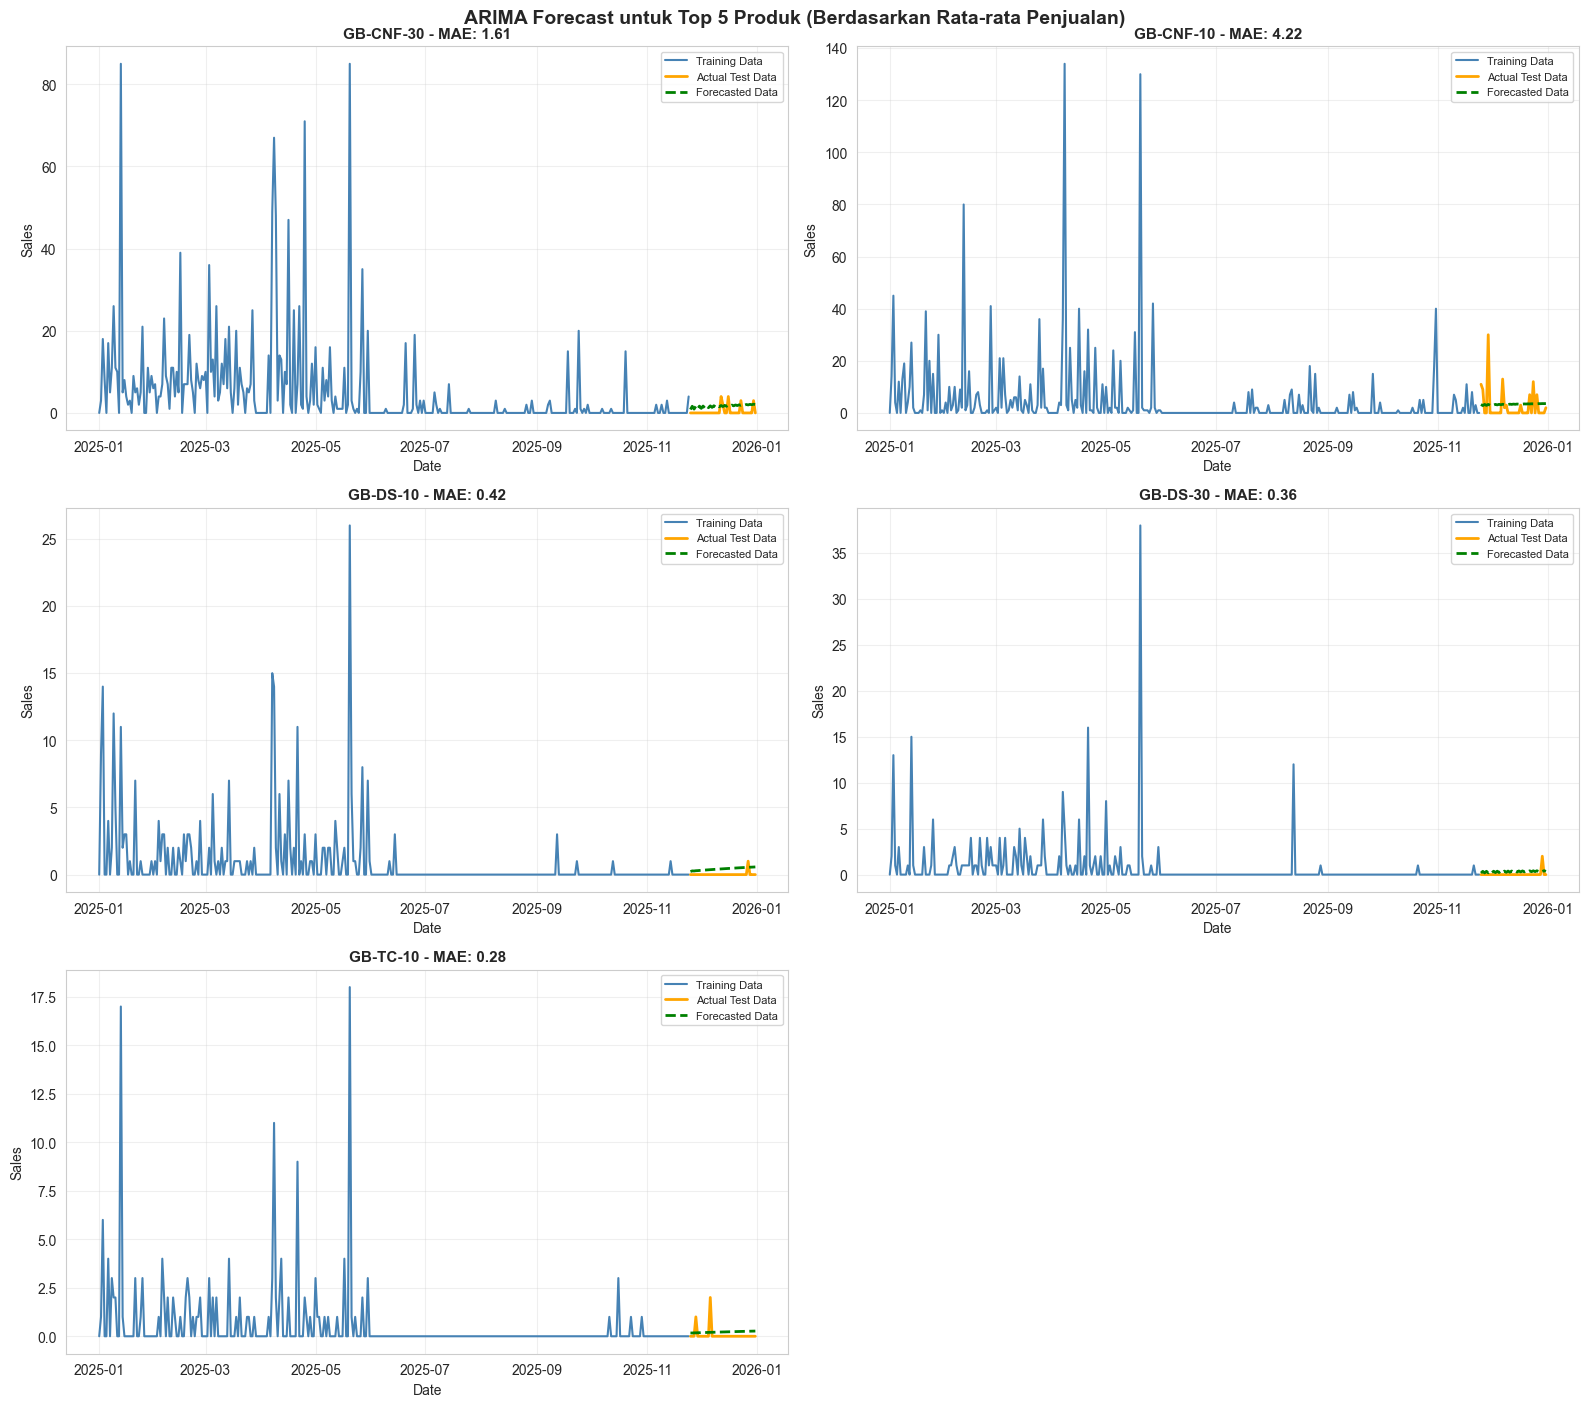

In [9]:

# Visualisasi forecast untuk 5 produk dengan penjualan tertinggi
# Hitung rata-rata penjualan per produk
avg_sales = dataset[product_columns].mean().sort_values(ascending=False)
top_5_products = avg_sales.head(5).index.tolist()

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, product in enumerate(top_5_products):
    if product in forecast_results and forecast_results[product]['success']:
        result = forecast_results[product]
        
        ax = axes[idx]
        
        # Plot training data
        ax.plot(result['train_data'].index, result['train_data'], 
                label='Training Data', color='steelblue', linewidth=1.5)
        
        # Plot test data
        ax.plot(result['test_data'].index, result['test_data'], 
                label='Actual Test Data', color='orange', linewidth=2)
        
        # Plot forecast
        ax.plot(result['test_data'].index, result['forecast'], 
                label='Forecasted Data', linestyle='--', color='green', linewidth=2)
        
        ax.set_title(f'{product} - MAE: {result["mae"]:.2f}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Sales')
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3)

# Sembunyikan subplot ke-6 yang tidak terpakai
axes[5].set_visible(False)

plt.tight_layout()
plt.suptitle('ARIMA Forecast untuk Top 5 Produk (Berdasarkan Rata-rata Penjualan)', 
             fontsize=14, fontweight='bold', y=1.002)
plt.show()


## 9. Distribusi Error Metrics

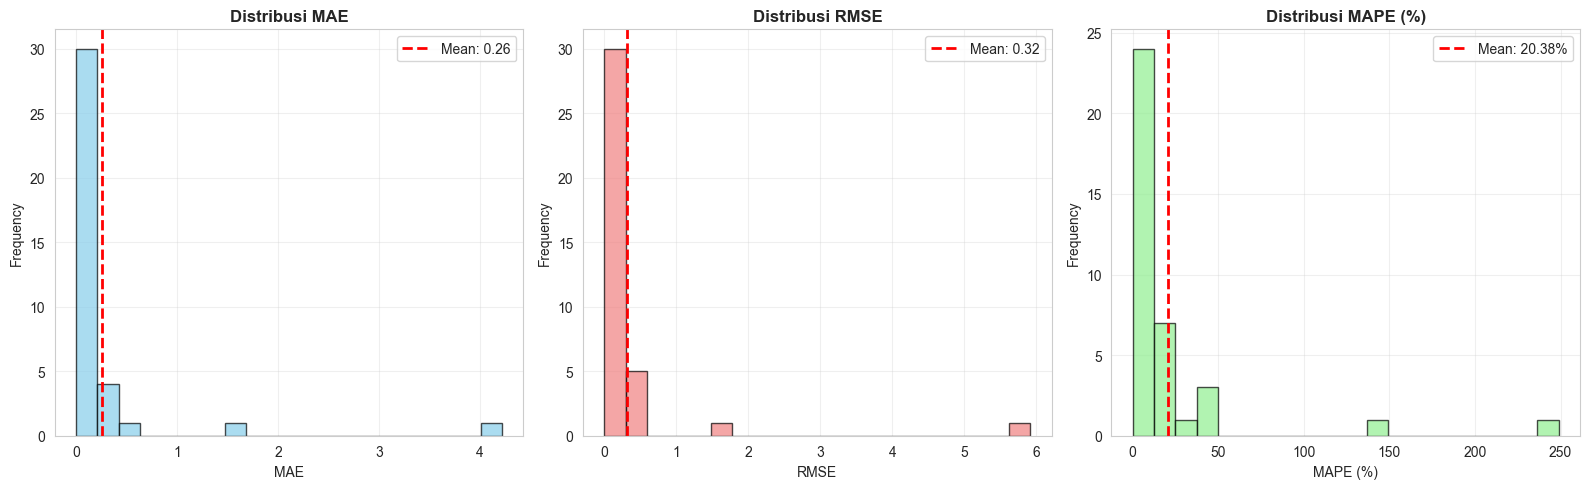

In [10]:
# Visualisasi distribusi error metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MAE Distribution
axes[0].hist(summary_df['MAE'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(summary_df['MAE'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {summary_df["MAE"].mean():.2f}')
axes[0].set_title('Distribusi MAE', fontsize=12, fontweight='bold')
axes[0].set_xlabel('MAE')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RMSE Distribution
axes[1].hist(summary_df['RMSE'], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].axvline(summary_df['RMSE'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {summary_df["RMSE"].mean():.2f}')
axes[1].set_title('Distribusi RMSE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('RMSE')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# MAPE Distribution
axes[2].hist(summary_df['MAPE (%)'], bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axes[2].axvline(summary_df['MAPE (%)'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {summary_df["MAPE (%)"].mean():.2f}%')
axes[2].set_title('Distribusi MAPE (%)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('MAPE (%)')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Export Hasil Forecasting ke CSV

Export hasil forecasting dalam 2 format:
1. **Summary metrics** per produk
2. **Detailed forecast** dengan data aktual vs prediksi

In [11]:
# 1. Export Summary Metrics per Produk
summary_export = summary_df.copy()
summary_export = summary_export.sort_values('MAE', ascending=True)

output_file_1 = 'arima_forecast_summary_per_produk.csv'
summary_export.to_csv(output_file_1, index=False, encoding='utf-8-sig')

print(f"✅ Summary metrics berhasil disimpan ke: {output_file_1}")
print(f"\nPreview (Top 10 produk dengan MAE terendah):")
print(summary_export.head(10).to_string(index=False))

✅ Summary metrics berhasil disimpan ke: arima_forecast_summary_per_produk.csv

Preview (Top 10 produk dengan MAE terendah):
    Produk ARIMA Order  MAE  RMSE  MAPE (%) Stationary  ADF p-value
      BR75   (2, 0, 2) 0.00  0.00      0.30         Ya       0.0000
      EC75   (2, 0, 2) 0.00  0.00      0.30         Ya       0.0000
 GB-DS-100   (2, 1, 2) 0.00  0.00      0.00      Tidak       0.1159
GB-CNF-250   (2, 0, 2) 0.00  0.00      0.30         Ya       0.0000
GB-LDR-250   (2, 0, 2) 0.00  0.00      0.30         Ya       0.0000
GB-MYB-100   (2, 0, 2) 0.00  0.00      0.30         Ya       0.0000
 GB-GF-250   (2, 0, 2) 0.00  0.00      0.30         Ya       0.0000
 GB-TC-250   (2, 0, 2) 0.00  0.00      0.30         Ya       0.0000
 GB-IB-100   (2, 0, 2) 0.01  0.01      0.61         Ya       0.0000
   AERIS10   (2, 0, 2) 0.01  0.01      0.91         Ya       0.0000


In [12]:
# 2. Export Detailed Forecast (Actual vs Predicted) untuk semua produk
detailed_forecast = []

for product, result in forecast_results.items():
    if result['success']:
        for date, actual, predicted in zip(result['test_data'].index, 
                                           result['test_data'].values, 
                                           result['forecast'].values):
            detailed_forecast.append({
                'Date': date,
                'Produk': product,
                'Actual_Sales': round(actual, 2),
                'Predicted_Sales': round(predicted, 2),
                'Error': round(actual - predicted, 2),
                'Absolute_Error': round(abs(actual - predicted), 2)
            })

detailed_df = pd.DataFrame(detailed_forecast)

output_file_2 = 'arima_forecast_detailed_per_produk.csv'
detailed_df.to_csv(output_file_2, index=False, encoding='utf-8-sig')

print(f"\n✅ Detailed forecast berhasil disimpan ke: {output_file_2}")
print(f"\nTotal records: {len(detailed_df)}")
print(f"\nPreview 10 baris pertama:")
print(detailed_df.head(10).to_string(index=False))


✅ Detailed forecast berhasil disimpan ke: arima_forecast_detailed_per_produk.csv

Total records: 1369

Preview 10 baris pertama:
      Date  Produk  Actual_Sales  Predicted_Sales  Error  Absolute_Error
2025-11-25 AERIS10           0.0             0.01  -0.01            0.01
2025-11-26 AERIS10           0.0             0.01  -0.01            0.01
2025-11-27 AERIS10           0.0             0.01  -0.01            0.01
2025-11-28 AERIS10           0.0             0.01  -0.01            0.01
2025-11-29 AERIS10           0.0             0.01  -0.01            0.01
2025-11-30 AERIS10           0.0             0.01  -0.01            0.01
2025-12-01 AERIS10           0.0             0.01  -0.01            0.01
2025-12-02 AERIS10           0.0             0.01  -0.01            0.01
2025-12-03 AERIS10           0.0             0.01  -0.01            0.01
2025-12-04 AERIS10           0.0             0.01  -0.01            0.01


## 11. Perbandingan Forecast dengan Aktual (Pivot Table)

In [13]:
# Buat pivot table untuk perbandingan actual vs predicted
pivot_actual = detailed_df.pivot_table(
    index='Date', 
    columns='Produk', 
    values='Actual_Sales'
)

pivot_predicted = detailed_df.pivot_table(
    index='Date', 
    columns='Produk', 
    values='Predicted_Sales'
)

# Export pivot tables
output_file_3 = 'arima_forecast_actual_pivot.csv'
output_file_4 = 'arima_forecast_predicted_pivot.csv'

pivot_actual.to_csv(output_file_3, encoding='utf-8-sig')
pivot_predicted.to_csv(output_file_4, encoding='utf-8-sig')

print(f"✅ Pivot table (Actual) disimpan ke: {output_file_3}")
print(f"✅ Pivot table (Predicted) disimpan ke: {output_file_4}")

print(f"\nPreview Actual Sales (5 produk pertama, 5 tanggal pertama):")
print(pivot_actual.iloc[:5, :5])

print(f"\nPreview Predicted Sales (5 produk pertama, 5 tanggal pertama):")
print(pivot_predicted.iloc[:5, :5])

✅ Pivot table (Actual) disimpan ke: arima_forecast_actual_pivot.csv
✅ Pivot table (Predicted) disimpan ke: arima_forecast_predicted_pivot.csv

Preview Actual Sales (5 produk pertama, 5 tanggal pertama):
Produk      AERIS10  BR45  BR75  EC45  EC75
Date                                       
2025-11-25      0.0   0.0   0.0   0.0   0.0
2025-11-26      0.0   0.0   0.0   0.0   0.0
2025-11-27      0.0   0.0   0.0   0.0   0.0
2025-11-28      0.0   0.0   0.0   0.0   0.0
2025-11-29      0.0   0.0   0.0   0.0   0.0

Preview Predicted Sales (5 produk pertama, 5 tanggal pertama):
Produk      AERIS10  BR45  BR75  EC45  EC75
Date                                       
2025-11-25     0.01  0.05   0.0  0.05   0.0
2025-11-26     0.01  0.05   0.0  0.05   0.0
2025-11-27     0.01  0.06   0.0  0.07   0.0
2025-11-28     0.01  0.07   0.0  0.07   0.0
2025-11-29     0.01  0.07   0.0  0.07   0.0


## 12. Kesimpulan dan Rekomendasi

In [14]:
print("\n" + "=" * 90)
print("KESIMPULAN DAN REKOMENDASI")
print("=" * 90)

# Hitung berapa produk yang berhasil di-forecast
successful_forecasts = sum(1 for r in forecast_results.values() if r['success'])

print(f"\n📊 HASIL FORECASTING:")
print(f"   • Total produk dianalisis: {len(product_columns)}")
print(f"   • Produk berhasil di-forecast: {successful_forecasts}")
print(f"   • Average MAE: {summary_df['MAE'].mean():.2f}")
print(f"   • Average RMSE: {summary_df['RMSE'].mean():.2f}")
print(f"   • Average MAPE: {summary_df['MAPE (%)'].mean():.2f}%")

print(f"\n🏆 PRODUK DENGAN PREDIKSI TERBAIK (Top 5):")
for idx, row in summary_df.nsmallest(5, 'MAE').iterrows():
    print(f"   {idx+1}. {row['Produk']}: MAE = {row['MAE']:.2f}")

print(f"\n⚠️  PRODUK YANG PERLU TUNING MODEL (Top 5):")
for idx, row in summary_df.nlargest(5, 'MAE').iterrows():
    print(f"   {idx+1}. {row['Produk']}: MAE = {row['MAE']:.2f}")

print(f"\n💡 REKOMENDASI:")
print(f"   1. Produk dengan MAE rendah dapat menggunakan model ARIMA (1,0,1)")
print(f"   2. Produk dengan MAE tinggi perlu tuning parameter ARIMA atau metode lain")
print(f"   3. Pertimbangkan model SARIMA untuk produk dengan pola musiman")
print(f"   4. Monitor performa model secara berkala dan update dengan data terbaru")

print("=" * 90)

# Export file list
print(f"\n📁 FILE YANG DIHASILKAN:")
print(f"   1. {output_file_1} - Summary metrics per produk")
print(f"   2. {output_file_2} - Detail forecast actual vs predicted")
print(f"   3. {output_file_3} - Pivot table actual sales")
print(f"   4. {output_file_4} - Pivot table predicted sales")
print("=" * 90)


KESIMPULAN DAN REKOMENDASI

📊 HASIL FORECASTING:
   • Total produk dianalisis: 37
   • Produk berhasil di-forecast: 37
   • Average MAE: 0.26
   • Average RMSE: 0.32
   • Average MAPE: 20.38%

🏆 PRODUK DENGAN PREDIKSI TERBAIK (Top 5):
   5. BR75: MAE = 0.00
   10. GB-CNF-250: MAE = 0.00
   13. GB-DS-100: MAE = 0.00
   16. EC75: MAE = 0.00
   19. GB-GF-250: MAE = 0.00

⚠️  PRODUK YANG PERLU TUNING MODEL (Top 5):
   8. GB-CNF-10: MAE = 4.22
   7. GB-CNF-30: MAE = 1.61
   18. GB-GF-10: MAE = 0.46
   12. GB-DS-10: MAE = 0.42
   6. GB-TP-CC: MAE = 0.38

💡 REKOMENDASI:
   1. Produk dengan MAE rendah dapat menggunakan model ARIMA (1,0,1)
   2. Produk dengan MAE tinggi perlu tuning parameter ARIMA atau metode lain
   3. Pertimbangkan model SARIMA untuk produk dengan pola musiman
   4. Monitor performa model secara berkala dan update dengan data terbaru

📁 FILE YANG DIHASILKAN:
   1. arima_forecast_summary_per_produk.csv - Summary metrics per produk
   2. arima_forecast_detailed_per_produk.csv